In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import PowerTransformer, StandardScaler

Dataset

In [39]:
df = pd.read_csv('../data/processed/olist_ml_dataset.csv')
df.head().T

,0,1,2,3,4
order_id,e481f51cbdc54678b7cc49136f2d6af7,53cdb2fc8bc7dce0b6741e2150273451,47770eb9100c2d0c44946d9cf07ec65d,949d5b44dbf5de918fe9c16f97b45f8a,ad21c59c0840e6cb83a9ceb5573f8159
customer_id,9ef432eb6251297304e76186b10a928d,b0830fb4747a6c6d20dea0b8c802d7ef,41ce2a54c0b03bf3443c3d931a367089,f88197465ea7920adcdbec7375364d82,8ab97904e6daea8866dbdbc4fb7aad2c
order_status,delivered,delivered,delivered,delivered,delivered
order_purchase_timestamp,2017-10-02 10:56:33,2018-07-24 20:41:37,2018-08-08 08:38:49,2017-11-18 19:28:06,2018-02-13 21:18:39
order_approved_at,2017-10-02 11:07:15,2018-07-26 03:24:27,2018-08-08 08:55:23,2017-11-18 19:45:59,2018-02-13 22:20:29
order_delivered_carrier_date,2017-10-04 19:55:00,2018-07-26 14:31:00,2018-08-08 13:50:00,2017-11-22 13:39:59,2018-02-14 19:46:34
order_delivered_customer_date,2017-10-10 21:25:13,2018-08-07 15:27:45,2018-08-17 18:06:29,2017-12-02 00:28:42,2018-02-16 18:17:02
order_estimated_delivery_date,2017-10-18,2018-08-13,2018-09-04,2017-12-15,2018-02-26
order_item_id,1.0,1.0,1.0,1.0,1.0
product_id,87285b34884572647811a353c7ac498a,595fac2a385ac33a80bd5114aec74eb8,aa4383b373c6aca5d8797843e5594415,d0b61bfb1de832b15ba9d266ca96e5b0,65266b2da20d04dbe00c5c2d3bb7859e


In [40]:
columns = ['order_id','customer_id','order_status','order_purchase_timestamp','order_approved_at','order_delivered_carrier_date','order_delivered_customer_date','order_estimated_delivery_date','order_item_id','product_id','seller_id','shipping_limit_date','product_name_lenght','product_description_lenght','product_photos_qty','customer_unique_id','customer_zip_code_prefix','customer_city','customer_state']
df.drop(columns=columns, inplace=True)
df.head().T

,0,1,2,3,4
price,29.99,118.7,159.9,45.0,19.9
freight_value,8.72,22.76,19.22,27.2,8.72
product_category_name,utilidades_domesticas,perfumaria,automotivo,pet_shop,papelaria
product_weight_g,500.0,400.0,420.0,450.0,250.0
product_length_cm,19.0,19.0,24.0,30.0,51.0
product_height_cm,8.0,13.0,19.0,10.0,15.0
product_width_cm,13.0,19.0,21.0,20.0,15.0
actual_delivery_days,8.0,13.0,9.0,13.0,2.0
delivery_delay_days,-8.0,-6.0,-18.0,-13.0,-10.0


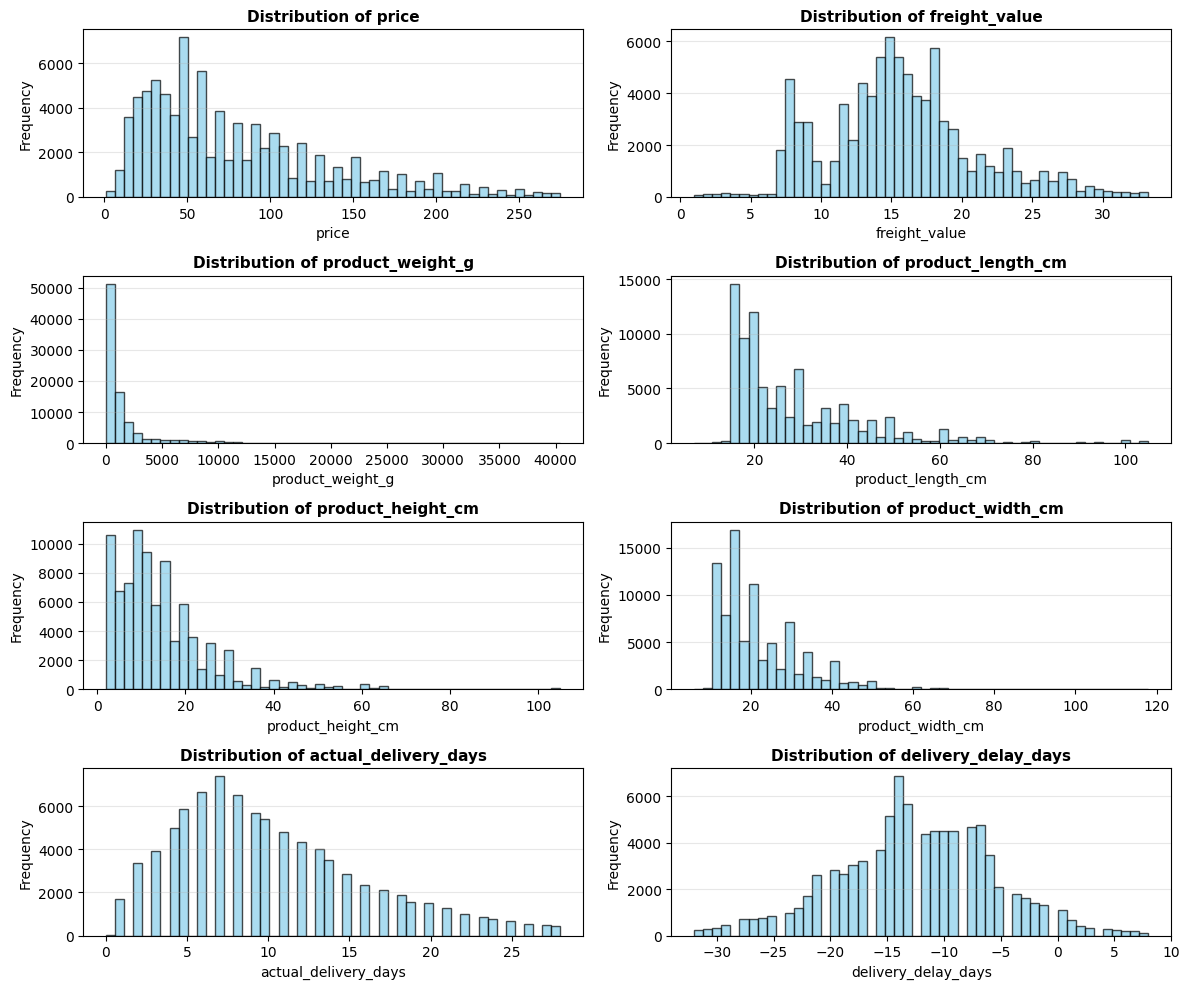

In [41]:
# Create distribution plots for all numerical features
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(12, 10))
axes = axes.ravel()

for idx, col in enumerate(numerical_cols):
    axes[idx].hist(df[col], bins=50, edgecolor='black', alpha=0.7, color='skyblue')
    axes[idx].set_title(f'Distribution of {col}', fontsize=11, fontweight='bold')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Frequency')
    axes[idx].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## Normalization

In [42]:
# Select only numerical columns
numerical_cols = df.select_dtypes(include=[np.number]).columns

price_col = "price"
power_cols = [
    c for c in numerical_cols
    if any(sub in c for sub in ["product_length", "product_weight", "product_height", "product_width"])
]
other_cols = [c for c in numerical_cols if c != price_col and c not in power_cols]

# Apply PowerTransformer to selected product dimension features
pt = PowerTransformer(method="yeo-johnson", standardize=True)
if power_cols:
    df[power_cols] = pt.fit_transform(df[power_cols])

# Apply StandardScaler to remaining numeric features except price
scaler = StandardScaler()
if other_cols:
    df[other_cols] = scaler.fit_transform(df[other_cols])

print(f"Power-transformed columns: {power_cols}")
print(f"Standard-scaled columns: {other_cols}")
print(f"Price column kept unscaled: {price_col}")
print(df[[*power_cols, *other_cols, price_col]].describe())

Power-transformed columns: ['product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']
Standard-scaled columns: ['freight_value', 'actual_delivery_days', 'delivery_delay_days']
Price column kept unscaled: price
       product_weight_g  product_length_cm  product_height_cm  \
count      8.652900e+04       8.652900e+04       8.652900e+04   
mean      -5.823677e-16      -1.760570e-15       3.948144e-16   
std        1.000006e+00       1.000006e+00       1.000006e+00   
min       -8.532933e+00      -5.495566e+00      -2.056236e+00   
25%       -7.935818e-01      -8.723873e-01      -5.558360e-01   
50%        5.861852e-03      -1.323122e-01      -1.437110e-02   
75%        7.279984e-01       8.320287e-01       7.234080e-01   
max        2.830457e+00       2.185144e+00       3.502027e+00   

       product_width_cm  freight_value  actual_delivery_days  \
count      8.652900e+04   8.652900e+04          8.652900e+04   
mean      -3.153260e-17  -1.873890e-16         -6.75

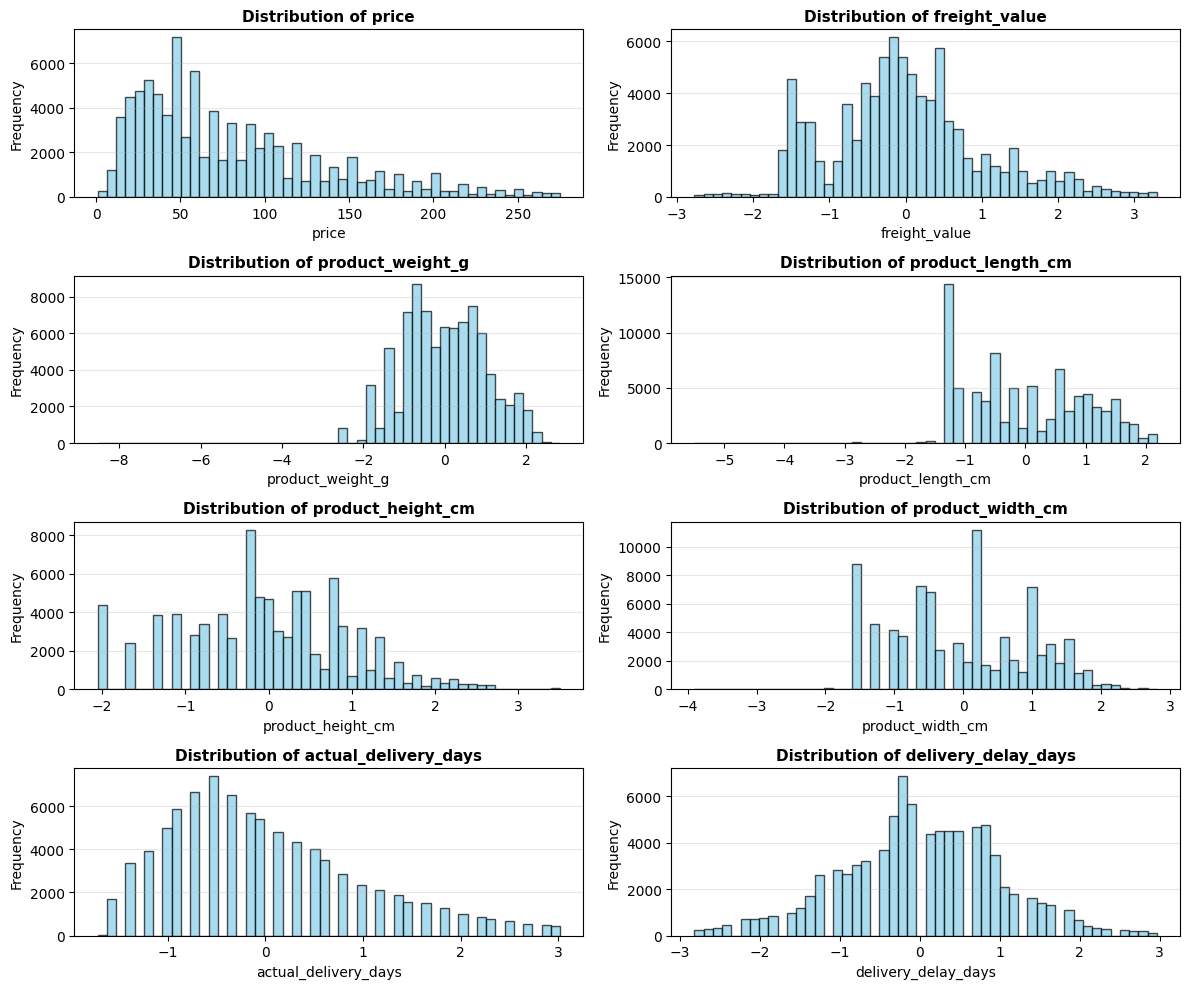

In [43]:
# Create distribution plots for all numerical features
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(12, 10))
axes = axes.ravel()

for idx, col in enumerate(numerical_cols):
    axes[idx].hist(df[col], bins=50, edgecolor='black', alpha=0.7, color='skyblue')
    axes[idx].set_title(f'Distribution of {col}', fontsize=11, fontweight='bold')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Frequency')
    axes[idx].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

Saving the dataset for later use in ml models

In [44]:
df.to_csv('../data/interim/olist_ml_processed_dataset.csv', index=False)